We will start by importing necessary libraries

In [ ]:
import numpy as np # linear algebra
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.patches as patches
import os
from PIL import Image
import cv2
import warnings
warnings.filterwarnings("ignore")


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/face-mask-detection/images/maksssksksss620.png
/kaggle/input/face-mask-detection/images/maksssksksss92.png
/kaggle/input/face-mask-detection/images/maksssksksss174.png
/kaggle/input/face-mask-detection/images/maksssksksss531.png
/kaggle/input/face-mask-detection/images/maksssksksss447.png
/kaggle/input/face-mask-detection/images/maksssksksss473.png
/kaggle/input/face-mask-detection/images/maksssksksss417.png
/kaggle/input/face-mask-detection/images/maksssksksss669.png
/kaggle/input/face-mask-detection/images/maksssksksss9.png
/kaggle/input/face-mask-detection/images/maksssksksss137.png
/kaggle/input/face-mask-detection/images/maksssksksss755.png
/kaggle/input/face-mask-detection/images/maksssksksss726.png
/kaggle/input/face-mask-detection/images/maksssksksss166.png
/kaggle/input/face-mask-detection/images/maksssksksss692.png
/kaggle/input/face-mask-detection/images/maksssksksss710.png
/kaggle/input/face-mask-detection/images/maksssksksss57.png
/kaggle/input/face-mask-dete

The dataset contains image files and XML files.
We will check what's actually there in the image and XML file has.

In [ ]:
!pip install xmltodict #installing the library to read XMl files
import xmltodict

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [ ]:
imagenames=[] #list of imagefile names
xmlnames=[] #list of xmlfile names
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if os.path.join(dirname, filename)[-3:]!="xml":
            imagenames.append(filename)
        else:
            xmlnames.append(filename)

In [ ]:
path_im="/kaggle/input/face-mask-detection/images/"  #path for an image folder 
path_an="/kaggle/input/face-mask-detection/annotations/" #path for xmlfiles folder

here you can see Xml file has properties of an image file including face locations and class it belong to..

In [ ]:
with open(path_an+xmlnames[0]) as f:
    print(xmltodict.parse(f.read()))

OrderedDict([('annotation', OrderedDict([('folder', 'images'), ('filename', 'maksssksksss644.png'), ('size', OrderedDict([('width', '301'), ('height', '400'), ('depth', '3')])), ('segmented', '0'), ('object', OrderedDict([('name', 'with_mask'), ('pose', 'Unspecified'), ('truncated', '0'), ('occluded', '0'), ('difficult', '0'), ('bndbox', OrderedDict([('xmin', '52'), ('ymin', '198'), ('xmax', '172'), ('ymax', '337')]))]))]))])


In [ ]:
## Code for finding the total no of labels in our dataset

listing=[]
for i in imagenames[:]:
    with open(path_an+i[:-4]+".xml") as fd:
        doc=xmltodict.parse(fd.read())
    temp=doc["annotation"]["object"]
    if type(temp)==list:
        for i in range(len(temp)):
            listing.append(temp[i]["name"])
    else:
        listing.append(temp["name"])

for i in  set(listing):
    print(i)

with_mask
without_mask
mask_weared_incorrect


In [ ]:
options={"with_mask":0,"without_mask":1,"mask_weared_incorrect":2} # mapping for predictions and analysis purpose

In [ ]:
def draw_bounding_box(input_image): #function to visualize images
    with open(path_an+input_image[:-4]+".xml") as fd:
        doc=xmltodict.parse(fd.read())
    image=plt.imread(os.path.join(path_im+input_image))
    fig,ax=plt.subplots(1)
    ax.axis("off")
    fig.set_size_inches(10,5)
    temp=doc["annotation"]["object"]
    if type(temp)==list:
        for i in range(len(temp)):
            if temp[i]["name"]=="with_mask":
                a,b,c,d=list(map(int,temp[i]["bndbox"].values()))
                patch=patches.Rectangle((a,b),c-a,d-b,linewidth=1, edgecolor='g',facecolor="none",)
                ax.add_patch(patch)
            if temp[i]["name"]=="without_mask":
                a,b,c,d=list(map(int,temp[i]["bndbox"].values()))     
                patch=patches.Rectangle((a,b),c-a,d-b,linewidth=1, edgecolor='r',facecolor="none",)
                ax.add_patch(patch)
            if temp[i]["name"]=="mask_weared_incorrect":
                a,b,c,d=list(map(int,temp[i]["bndbox"].values()))
                patch=patches.Rectangle((a,b),c-a,d-b,linewidth=1, edgecolor='y',facecolor="none",)
                ax.add_patch(patch)
    else:
        a,b,c,d=list(map(int,temp["bndbox"].values()))
        edgecolor={"with_mask":"g","without_mask":"g","mask_weared_incorrect":"y"}
        patch=patches.Rectangle((a,b),d-b,c-a,linewidth=1, edgecolor=edgecolor[temp["name"]],facecolor="none",)
    ax.imshow(image)
    ax.add_patch(patch)

Now let's visualize some of the images.

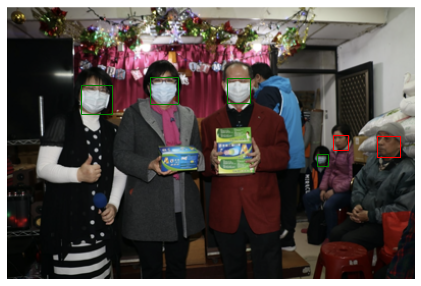

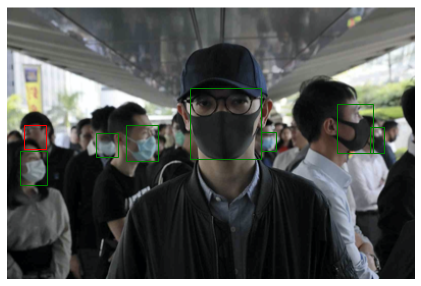

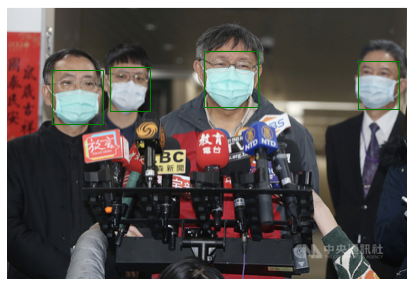

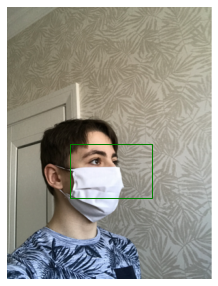

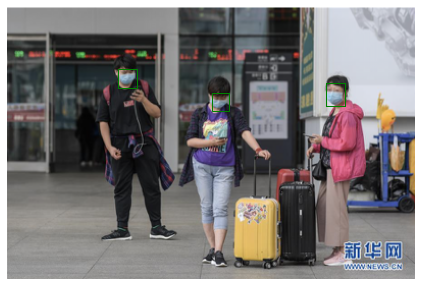

In [ ]:
for i in range(0,5):
    draw_bounding_box(imagenames[i])

In [ ]:
def make_dataset(no_of_images): #function to make dataset
    image_tensor=[]
    label_tensor=[]
    for i,j in enumerate(no_of_images):
        with open(path_an+j[:-4]+".xml") as fd:
            doc=xmltodict.parse(fd.read())
        if type(doc["annotation"]["object"])!=list:
            temp=doc["annotation"]["object"]
            a,b,c,d=list(map(int,temp["bndbox"].values()))
            label=options[temp["name"]]
            image=transforms.functional.crop(Image.open(path_im+j).convert("RGB"), b,a,d-b,c-a)
            image_tensor.append(my_transform(image))
            label_tensor.append(torch.tensor(label))
        else:
            temp=doc["annotation"]["object"]
            for k in range(len(temp)):
                a,b,c,d=list(map(int,temp[k]["bndbox"].values()))
                label=options[temp[k]["name"]]
                image=transforms.functional.crop(Image.open(path_im+j).convert("RGB"), b,a,d-b,c-a)
                image_tensor.append(my_transform(image))
                label_tensor.append(torch.tensor(label))
                
    final_dataset=[[k,l] for k,l in zip(image_tensor,label_tensor)]
    return tuple(final_dataset)

In [ ]:
#importing neccessary libraries for deeplearning task..
import torch
from torchvision import datasets,transforms,models
from torch.utils.data import Dataset,DataLoader

my_transform=transforms.Compose([transforms.Resize((226,226)),
                                 transforms.ToTensor()])

dataset=make_dataset(imagenames) #making a datset
train_size=int(len(dataset)*0.8)
test_size=len(dataset)-train_size
batch_size=32
trainset,testset=torch.utils.data.random_split(dataset,[train_size,test_size])
train_loader =DataLoader(dataset=trainset,batch_size=batch_size,shuffle=True)
test_loader =DataLoader(dataset=testset,batch_size=batch_size,shuffle=True)

Now lets see how the images in the dataset looks like..

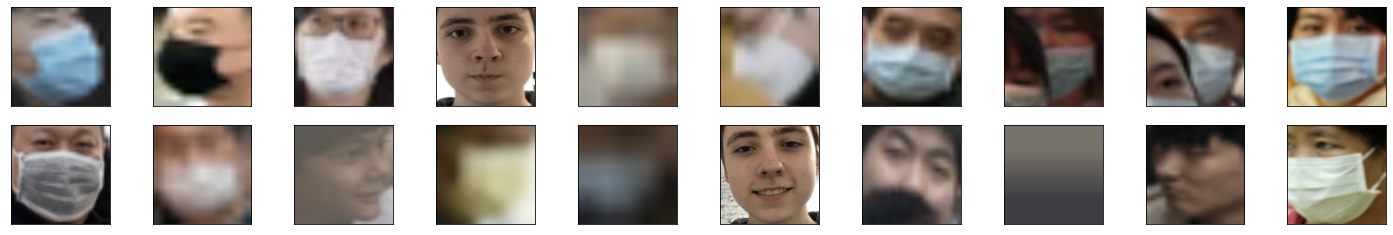

In [ ]:
dataiter=iter(train_loader) 
images,labels=dataiter.next()
images=images.numpy()

fig=plt.figure(figsize=(25,4))
for idx in np.arange(20):
    ax=fig.add_subplot(2,20/2,idx+1,xticks=[],yticks=[])
    plt.imshow(np.transpose(images[idx],(1,2,0)))

In [ ]:
# We Will use pretrained resnet34 layer model.
resnet=models.resnet34(pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/checkpoints/resnet34-333f7ec4.pth


In [ ]:
for param in resnet.parameters():
    param.requires_grad=False

In [ ]:
import torch.nn as nn
n_inputs=resnet.fc.in_features
last_layer=nn.Linear(n_inputs,3)
resnet.fc.out_features=last_layer

if torch.cuda.is_available():
    resnet.cuda()
    
print(resnet.fc.out_features)

Linear(in_features=512, out_features=3, bias=True)


In [ ]:
if torch.cuda.is_available(): #checking for GPU availability
    device = torch.device("cuda")
    print('There are %d GPU(s) available.' % torch.cuda.device_count())
    print('We will use the GPU:', torch.cuda.get_device_name(0))

else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla P100-PCIE-16GB


In [ ]:
for paramet in resnet.parameters():
    paramet.requires_grad=True

In [ ]:
import torch.optim as optim

criterion=nn.CrossEntropyLoss()

optimizer=optim.SGD(resnet.parameters(),lr=0.001)

## Training the model

In [ ]:
n_epochs=3

for epoch in range(1,n_epochs+1):
    train_loss = 0.0


  ########################  TRAIN THE MODEL #################
    for batch,(data,target) in enumerate(train_loader):
    
    
        if torch.cuda.is_available():
            data , target = data.cuda(), target.cuda()
    
        optimizer.zero_grad()
        output=resnet(data)
        loss=criterion(output,target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        if batch%20==19:
            print("Epoch {}, batch {}, training loss {}".format(epoch, batch+1,train_loss/20))
        train_loss = 0.0

Epoch 1, batch 20, training loss 0.167203950881958
Epoch 1, batch 40, training loss 0.09560819864273071
Epoch 1, batch 60, training loss 0.042661866545677184
Epoch 1, batch 80, training loss 0.015892356634140015
Epoch 1, batch 100, training loss 0.03281499743461609
Epoch 2, batch 20, training loss 0.004256555438041687
Epoch 2, batch 40, training loss 0.03127885758876801
Epoch 2, batch 60, training loss 0.01312292367219925
Epoch 2, batch 80, training loss 0.023117154836654663
Epoch 2, batch 100, training loss 0.029121899604797365
Epoch 3, batch 20, training loss 0.020589269697666168
Epoch 3, batch 40, training loss 0.02461782991886139
Epoch 3, batch 60, training loss 0.04838932156562805
Epoch 3, batch 80, training loss 0.012064135074615479
Epoch 3, batch 100, training loss 0.009404593706130981


## Testing

In [ ]:
#########Testing##########
test_loss=0.0
acc=0
resnet.eval()

for data,target in test_loader:
    if torch.cuda.is_available():
        data,target=data.cuda(),target.cuda()
    output=resnet(data)
    loss=criterion(output,target)
    test_loss+=loss.item()
    _,pred=torch.max(output,1)
    predicted=pred.numpy()[:,np.newaxis] if not torch.cuda.is_available() else pred.cpu().numpy()[:,np.newaxis]
    actual=target.numpy()[:,np.newaxis] if not torch.cuda.is_available() else target.cpu().numpy()[:,np.newaxis]
    acc+=np.sum(predicted==actual)/len(target.cpu().numpy())

Average_loss=test_loss/len(test_loader)
Average_acc=acc/len(test_loader)

print("Avg total loss is {:.6f}".format(Average_loss))
print("Avg accuracy is {:.6f}".format(Average_acc))


Avg total loss is 0.376444
Avg accuracy is 0.936138


In [ ]:
torch.save(resnet,open("resnet_model_face_mask","wb")) # saving the trained model.

## Now we will load the saved model and will see how it works.

In [ ]:
device = torch.device("cuda")
model=torch.load(open("/kaggle/working/resnet_model_face_mask","rb"),map_location=device) #loading the model

In [ ]:
!pip install mtcnn #installing library for predicting faces

     |████████████████████████████████| 2.3 MB 2.8 MB/s eta 0:00:01
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [ ]:
from mtcnn import MTCNN
detect=MTCNN()

In [ ]:
def trans(bndbox,newimage):
    a,b,c,d=bndbox["box"]
    image_crop=transforms.functional.crop(newimage, b,a,d-b,c-a)
    my_transform=transforms.Compose([transforms.Resize((226,226)),
                                     transforms.RandomCrop((224,224)),
                                     transforms.ToTensor()])(image_crop)
    return my_transform

In [ ]:
def tag_plot(bndbox,filepath,predicted):
    configut=["with_mask","without_mask","mask_weared_incorrect"]
    x=plt.imread(filepath)
    fig,ax=plt.subplots(1)
    ax.axis("off")
    fig.set_size_inches(15,10)
    for i,j in zip(bndbox,predicted):
        a,b,c,d=i["box"]
        patch=patches.Rectangle((a,b),c,d,linewidth=1, edgecolor='r',facecolor="none",)
        ax.imshow(x)
        ax.text(a, b, configut[predicted[0]], size=10,
                style='italic',verticalalignment="bottom", horizontalalignment="left",color="blue")
        ax.add_patch(patch)

In [ ]:
model=model.eval()
def testing(filepath):
    configut=["with_mask","without_mask","mask_weared_incorrect"]
    img = cv2.cvtColor(cv2.imread(filepath), cv2.COLOR_BGR2RGB)
    newimage=Image.open(filepath).convert("RGB")
    bndbox=detect.detect_faces(img)
    if len(bndbox)==1:
        image_pred=trans(bndbox[0],newimage).unsqueeze(0)
        _, pred=torch.max(model(image_pred.to(device)),1)
        tag_plot(bndbox,filepath,predicted=pred)
    else:
        predicted=[]
        for i in bndbox:
            image_pred=trans(i,newimage).unsqueeze(0)
            _, pred=torch.max(model(image_pred.to(device)),1)
            predicted.append(pred)
        tag_plot(bndbox,filepath,predicted)

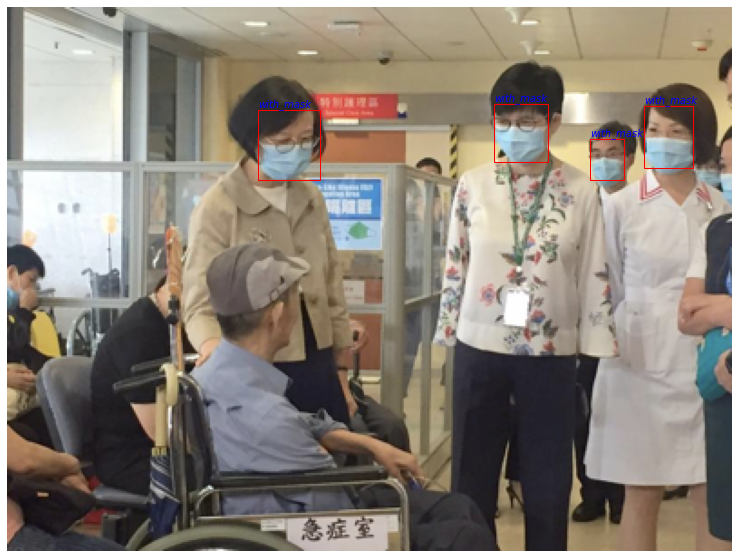

In [ ]:
testing(path_im+imagenames[118]) # if you have images you can test them using this function..

### Thank you